In [ ]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

# Load a small sample to inspect structure and overlap
df_pos = pd.read_csv('../data/raw/bkk_positions.csv', dtype=str, nrows=500000)
df_del = pd.read_csv('../data/raw/bkk_delays.csv', dtype=str, nrows=500000)

print(f"Positions shape: {df_pos.shape}")
print(f"Delays shape: {df_del.shape}")

Positions Timeframe: 2026-04-15 22:10:17 to 2026-04-20 12:33:32
Delays Timeframe:    1970-01-01 00:00:40 to 2026-04-20 09:05:11


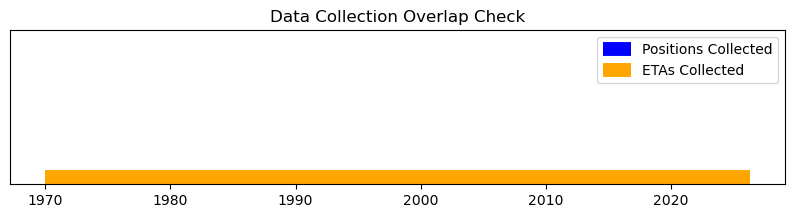

In [ ]:
# Convert unix timestamps to datetime
pos_time = pd.to_datetime(pd.to_numeric(df_pos['vehicle.timestamp'], errors='coerce'), unit='s')
del_time = pd.to_datetime(pd.to_numeric(df_del['tripUpdate.timestamp'], errors='coerce'), unit='s')

print(f"Positions Timeframe: {pos_time.min()} to {pos_time.max()}")
print(f"Delays Timeframe:    {del_time.min()} to {del_time.max()}")

# Plotting the timeline
plt.figure(figsize=(10, 2))
plt.hlines(1, pos_time.min(), pos_time.max(), color='blue', lw=10, label='Positions Collected')
plt.hlines(0.8, del_time.min(), del_time.max(), color='orange', lw=10, label='ETAs Collected')
plt.yticks([])
plt.legend()
plt.title("Data Collection Overlap Check")
plt.show()

In [ ]:
pos_ids = set(df_pos['vehicle.trip.tripId'].dropna())
del_ids = set(df_del['tripUpdate.trip.tripId'].dropna())

overlap = pos_ids.intersection(del_ids)

print(f"Unique Trips in Positions: {len(pos_ids)}")
print(f"Unique Trips in Delays: {len(del_ids)}")
print(f"Trips existing in BOTH: {len(overlap)}")

if len(overlap) == 0:
    print("WARNING: Zero matching Trip IDs! The datasets contain completely different vehicles.")
else:
    print(f"Sample matched IDs: {list(overlap)[:5]}")

Unique Trips in Positions: 26686
Unique Trips in Delays: 21434
Trips existing in BOTH: 15586
Sample matched IDs: ['D12687158', 'D1062639247', 'D1243621', 'D1159813108', 'D119282954']


In [ ]:
# Grab the first valid nested array from the delays dataset
sample_array_str = df_del['tripUpdate.stopTimeUpdate'].dropna().iloc[0]

# Safely parse the python string representation into an actual list of dictionaries
parsed_array = ast.literal_eval(sample_array_str)

print(f"Number of upcoming stops for this vehicle: {len(parsed_array)}\n")

# Flatten it into a temporary dataframe to look at the columns
df_stops_sample = pd.json_normalize(parsed_array)
print("Available ETA Features for ML:")
display(df_stops_sample.head())

Number of upcoming stops for this vehicle: 29

Available ETA Features for ML:


,stopId,stopSequence,arrival.time,arrival.uncertainty,departure.time,departure.uncertainty
0,F02202,1,1776619253,0,1776619967,0
1,F02181,2,1776620049,0,1776620049,0
2,F02044,3,1776620207,0,1776620207,0
3,F02035,4,1776620242,0,1776620242,0
4,F02033,5,1776620259,0,1776620259,0


Scanning bkk_positions.csv for hourly data volume...
Processed chunk 12...
Processing complete! Generating plot...


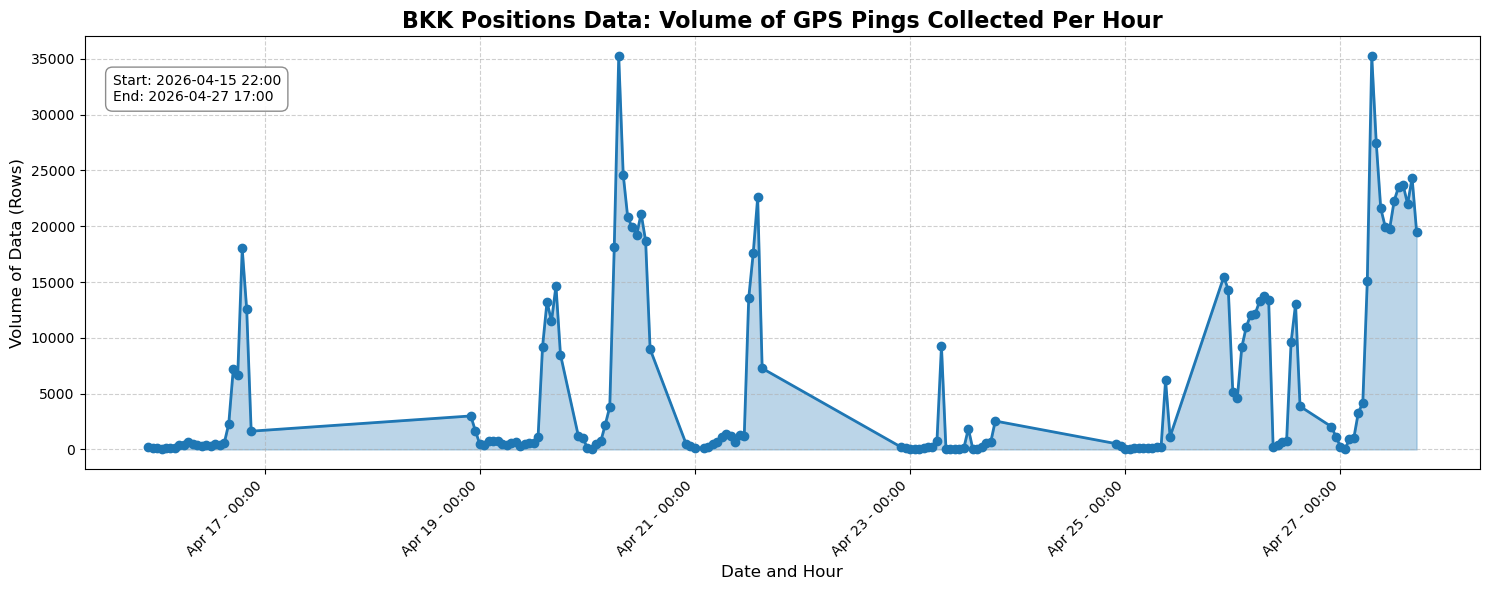

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Scanning bkk_positions.csv for hourly data volume...")

file_path = '../data/raw/bkk_positions.csv'
hourly_counts = pd.Series(dtype=float)

START_2026 = 1767225600

# Read the file in memory-safe chunks
# on_bad_lines='skip' ensures that one corrupted row won't break the whole script
chunk_iterator = pd.read_csv(
    file_path, 
    usecols=['vehicle.timestamp'], 
    dtype=str, 
    chunksize=250000, 
    on_bad_lines='skip'
)

for i, chunk in enumerate(chunk_iterator):
    # 1. Convert string to numeric, dropping any corrupted text/nulls
    timestamps = pd.to_numeric(chunk['vehicle.timestamp'], errors='coerce').dropna()
    timestamps = timestamps[(timestamps >= START_2026)]
    # 2. Convert unix timestamps to readable datetimes
    datetimes = pd.to_datetime(timestamps, unit='s')
    
    # 3. Round every ping down to the nearest hour (e.g. 14:35 -> 14:00) and count them
    chunk_hourly = datetimes.dt.floor('h').value_counts()
    
    # 4. Add this chunk's counts to our master total
    hourly_counts = hourly_counts.add(chunk_hourly, fill_value=0)
    print(f"\rProcessed chunk {i+1}...", end="", flush=True)

print("\nProcessing complete! Generating plot...")

# Sort the timeline chronologically from oldest to newest
hourly_counts = hourly_counts.sort_index()

# ---------------------------------------------------------
# CREATE THE VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(15, 6))

# A line plot with area fill is much cleaner for time-series data than a bar chart
plt.plot(hourly_counts.index, hourly_counts.values, marker='o', linestyle='-', color='#1f77b4', linewidth=2)
plt.fill_between(hourly_counts.index, hourly_counts.values, color='#1f77b4', alpha=0.3)

plt.title('BKK Positions Data: Volume of GPS Pings Collected Per Hour', fontsize=16, fontweight='bold')
plt.xlabel('Date and Hour', fontsize=12)
plt.ylabel('Volume of Data (Rows)', fontsize=12)

# Format the x-axis to show readable dates and hours without overlapping
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d - %H:00'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, ha='right')

# Add a grid to make it easier to read specific hours
plt.grid(True, linestyle='--', alpha=0.6)

# Display the exact start and end dates in the corner
start_str = hourly_counts.index.min().strftime('%Y-%m-%d %H:00')
end_str = hourly_counts.index.max().strftime('%Y-%m-%d %H:00')
plt.annotate(f'Start: {start_str}\nEnd: {end_str}', 
             xy=(0.02, 0.85), xycoords='axes fraction', 
             bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.9))

plt.tight_layout()
plt.show()

Scanning bkk_delays.csv for hourly data volume...
Reading target column: 'tripUpdate.timestamp'
Processed chunk 27... 
Processing complete! Generating plot...


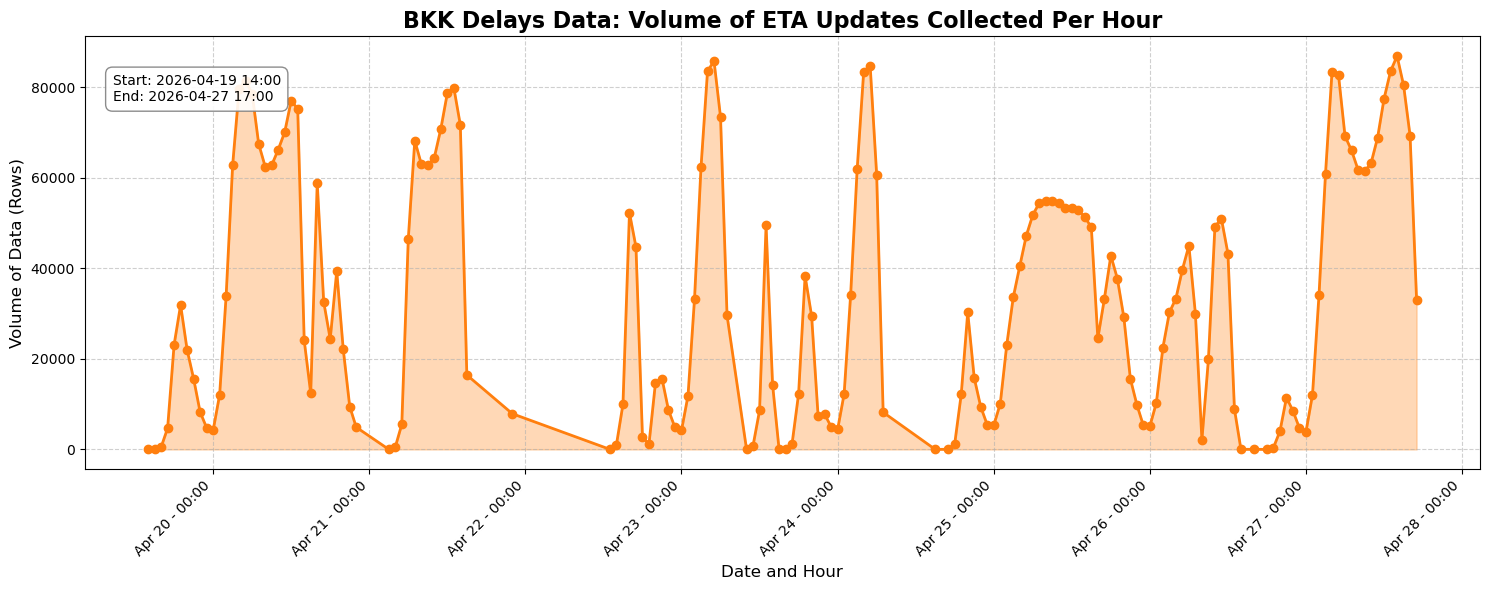

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Scanning bkk_delays.csv for hourly data volume...")

file_path = '../data/raw/bkk_delays.csv'

# 1. Safely grab the exact name of the timestamp column
df_header = pd.read_csv(file_path, nrows=0)
time_cols = [col for col in df_header.columns if 'timestamp' in col.lower()]

if not time_cols:
    print(f"Error: Could not find a timestamp column. Available columns: {df_header.columns.tolist()[:10]}")
else:
    target_col = time_cols[0]
    print(f"Reading target column: '{target_col}'")

    hourly_counts = pd.Series(dtype=float)

    # 2. Read the massive file in memory-safe chunks
    chunk_iterator = pd.read_csv(
        file_path, 
        usecols=[target_col], 
        dtype=str, 
        chunksize=250000, 
        on_bad_lines='skip'
    )

    for i, chunk in enumerate(chunk_iterator):
        # Convert string to numeric, dropping any corrupted text/nulls
        timestamps = pd.to_numeric(chunk[target_col], errors='coerce').dropna()
        timestamps = timestamps[(timestamps >= START_2026)]
        # Convert unix timestamps to readable datetimes
        datetimes = pd.to_datetime(timestamps, unit='s')
        
        # Round every ETA update down to the nearest hour ('h')
        chunk_hourly = datetimes.dt.floor('h').value_counts()
        
        # Add this chunk's counts to our master total
        hourly_counts = hourly_counts.add(chunk_hourly, fill_value=0)
        print(f"\rProcessed chunk {i+1}... ", end="", flush=True)

    print("\nProcessing complete! Generating plot...")

    # Sort the timeline chronologically
    hourly_counts = hourly_counts.sort_index()

    # ---------------------------------------------------------
    # CREATE THE VISUALIZATION
    # ---------------------------------------------------------
    plt.figure(figsize=(15, 6))

    # Using orange to easily distinguish it from the blue positions plot
    plt.plot(hourly_counts.index, hourly_counts.values, marker='o', linestyle='-', color='#ff7f0e', linewidth=2)
    plt.fill_between(hourly_counts.index, hourly_counts.values, color='#ff7f0e', alpha=0.3)

    plt.title('BKK Delays Data: Volume of ETA Updates Collected Per Hour', fontsize=16, fontweight='bold')
    plt.xlabel('Date and Hour', fontsize=12)
    plt.ylabel('Volume of Data (Rows)', fontsize=12)

    # Format the x-axis
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d - %H:00'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45, ha='right')

    plt.grid(True, linestyle='--', alpha=0.6)

    # Display start and end dates
    start_str = hourly_counts.index.min().strftime('%Y-%m-%d %H:00')
    end_str = hourly_counts.index.max().strftime('%Y-%m-%d %H:00')
    plt.annotate(f'Start: {start_str}\nEnd: {end_str}', 
                 xy=(0.02, 0.85), xycoords='axes fraction', 
                 bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.9))

    plt.tight_layout()
    plt.show()

In [ ]:
import ast
import re
import pandas as pd
import numpy as np

print("Loading Positions Data...")
df = pd.read_csv('../data/raw/bkk_positions.csv', dtype=str) 
df['vehicle.timestamp'] = pd.to_numeric(df['vehicle.timestamp'], errors='coerce')

# ---------------------------------------------------------
# PRO FILTER 1: THE TIMELINE SANITY CHECK
# ---------------------------------------------------------
# Filter out the 1970 Unix glitches (Unix time 0). 
# We set a strict floor of April 1, 2026 (1775000000)
MIN_VALID_UNIX_TIME = 1775000000
df = df[df['vehicle.timestamp'] > MIN_VALID_UNIX_TIME]

# ---------------------------------------------------------
# PRO FILTER 2: PRE-FILTERING BY INTERSECTION
# ---------------------------------------------------------
# Extract the exact physical trips we have. We will use this to ignore 
# gigabytes of useless ETA data in the next step.
valid_physical_trips = set(df['vehicle.trip.tripId'].dropna())
print(f"Tracking {len(valid_physical_trips)} valid physical trips...")


print("Processing Trip Updates (ETA Data) in chunks...")

def process_delays_chunk(chunk):
    if 'tripUpdate.trip.tripId' in chunk.columns:
        chunk = chunk.rename(columns={'tripUpdate.trip.tripId': 'vehicle.trip.tripId'})

    # INSTANT OPTIMIZATION: Drop ETAs for buses we don't physically have
    chunk = chunk[chunk['vehicle.trip.tripId'].isin(valid_physical_trips)]
    
    if chunk.empty:
        return pd.DataFrame() # Skip empty chunks entirely

    def safe_parse_list(val):
        if pd.isna(val):
            return []
        try:
            clean_val = re.sub(r'\bnan\b', 'None', str(val))
            return ast.literal_eval(clean_val)
        except Exception:
            return []

    chunk['tripUpdate.stopTimeUpdate'] = chunk['tripUpdate.stopTimeUpdate'].apply(safe_parse_list)
    
    exploded = chunk.explode('tripUpdate.stopTimeUpdate').dropna(subset=['tripUpdate.stopTimeUpdate'])

    def extract_arrival_time(stop_dict):
        if isinstance(stop_dict, dict):
            arrival = stop_dict.get('arrival', {})
            if isinstance(arrival, dict):
                return arrival.get('time', np.nan)
        return np.nan

    exploded['arrival_timestamp'] = exploded['tripUpdate.stopTimeUpdate'].apply(extract_arrival_time)

    exploded = exploded.dropna(subset=['arrival_timestamp'])
    exploded['arrival_timestamp'] = exploded['arrival_timestamp'].astype(float)
    
    # Filter 1970 glitches out of the ETA dataset
    exploded = exploded[exploded['arrival_timestamp'] > MIN_VALID_UNIX_TIME]

    exploded = exploded.sort_values('arrival_timestamp')
    
    return exploded[['vehicle.trip.tripId', 'arrival_timestamp']]

chunk_size = 50000  # We can increase chunk size safely now because of the intersection filter
eta_chunks = []

# Process the entire 6GB file (-1)
chunks_amount = -1 
for i, chunk in enumerate(pd.read_csv('../data/raw/bkk_delays.csv', dtype=str, chunksize=chunk_size)):
    processed_chunk = process_delays_chunk(chunk)
    if not processed_chunk.empty:
        eta_chunks.append(processed_chunk)
    
    # Print status every 10 chunks to keep output clean
    if i % 10 == 0:
        print(f"\rProcessed chunk {i}...      ", end="", flush=True)

    if chunks_amount != -1 and i + 1 >= chunks_amount:
        print(f"\nTest limit reached. Stopping after {chunks_amount} chunks.")
        break
print("\nExtraction complete.")

print("Concatenating processed chunks...")
eta_features = pd.concat(eta_chunks)

print("Cleaning nulls and sorting data for merge_asof...")
df = df.dropna(subset=['vehicle.timestamp', 'vehicle.trip.tripId'])
eta_features = eta_features.dropna(subset=['arrival_timestamp', 'vehicle.trip.tripId'])

df = df.sort_values('vehicle.timestamp')
eta_features = eta_features.sort_values('arrival_timestamp')

# ---------------------------------------------------------
# THE GRAND MERGE
# ---------------------------------------------------------
print("Executing asynchronous time-series merge...")

df = pd.merge_asof(
    left=df, 
    right=eta_features, 
    by='vehicle.trip.tripId',           
    left_on='vehicle.timestamp',        
    right_on='arrival_timestamp',       
    direction='forward'                 
)

df = df.dropna(subset=['arrival_timestamp'])

# ---------------------------------------------------------
# CREATE THE TARGET VARIABLE
# ---------------------------------------------------------
df['seconds_to_next_stop'] = df['arrival_timestamp'] - df['vehicle.timestamp']

# Strict bounds: Target must be in the future (>0) and less than 2 hours (7200s) away. 
# Anything longer in city transit is an API error.
df = df[(df['seconds_to_next_stop'] > 0) & (df['seconds_to_next_stop'] < 7200)]

print(f"FINAL DATASET READY FOR ML: {df.shape}")

print("Saving perfectly cleaned data to CSV...")
df.to_csv('../data/processed/bkk_cleaned.csv', index=False)
print("Done! You are ready for EDA.")

Loading Positions Data...
Tracking 16912 valid physical trips...
Processing Trip Updates (ETA Data) in chunks...
Processed chunk 130...      
Extraction complete.
Concatenating processed chunks...
Cleaning nulls and sorting data for merge_asof...
Executing asynchronous time-series merge...
FINAL DATASET READY FOR ML: (41484, 20)
Saving perfectly cleaned data to CSV...
Done! You are ready for EDA.
